# Lecture 8 — The JOSH Solver: Production Radiative Transfer

*Stellar Spectroscopy from Scratch — a torch/MPS implementation, with each part validated against reference calculations*

*Yuan-Sen Ting*

*This lecture rebuilds the Kurucz/ATLAS JOSH moment-solver **algorithm** as clean **`torch`** that runs on the GPU (Apple **MPS** or **CUDA**, with a CPU fallback). It imports neither `kgpu` nor `pykurucz`, and it does not depend on the NumPy lecture. The scoped taught-path inputs are the opacity slabs from the preceding synthesis stage (`L6.npz`) and the fixed JOSH operator tables; source arrays and flux arrays are comparison-only references, not inputs to the solver.*

---

**Learning objectives.** By the end of this lecture you will be able to:

- Derive the moment-equation form of plane-parallel transfer and identify the Eddington closure used by JOSH.
- Interpret the three fixed JOSH tables: the optical-depth grid `XTAU`, the lambda-like operator `COEFJ`, and the surface-flux weights `CH`.
- Build optical depth with Kurucz's parabolic quadrature, map source terms onto the fixed grid, and solve the scattering source function.
- Run the full JOSH solve as batched torch tensor operations over wavelength, using fp32 where the production iteration used single precision.
- Reproduce the shipped production spectrum within the documented torch/MPS numerical floor, while keeping the scoped fixture and comparison boundaries explicit.

## Introduction

Lecture 7 used the formal solution of transfer: prescribe the LTE source, integrate against an $E_2$ kernel, and recover an emergent flux. It was physically transparent and very close to the production spectrum, but not identical in the strongest cores. This lecture rebuilds the production path responsible for that remaining difference.

The production solver is called **JOSH**. It maps each wavelength onto a fixed optical-depth grid, solves moment equations with a precomputed lambda-like operator, iterates the source when scattering matters, and forms the emergent surface flux with fixed weights. The algorithm is old and compact; the GPU lesson is to make wavelength the batch axis so the whole spectral window is a tensor program rather than a Python loop over wavelengths.

![The JOSH moment solver: opacity to optical depth, a map onto a fixed Eddington grid, a scattering iteration for the source, and a weighted surface flux.](resources/figures/s7_josh.png)

## Load the data and choose the device

The code path is self-contained: it imports no production solver and all source, mapping, iteration, and flux operations are written here in torch. The data path has a scoped fixture boundary appropriate to this transfer-kernel lesson: the opacity slabs are products of earlier continuum and line-opacity stages, and the JOSH operator tables are fixed numerical tables extracted from the Kurucz/ATLAS implementation rather than generated in this notebook.

The next section audits every loaded array so the distinction is explicit. The LTE source is computed from the atmosphere temperatures, not imported from any solver, and the shipped flux arrays are used only after the solve as parity targets. The JOSH operator arrays (`XTAU`, `COEFJ`, `CH`) are fixed method constants: the same Eddington-grid quadrature/Lambda tables for every star and every wavelength, shipped as data in the same sense as Harris Voigt or continuum cross-section tables, not as an output of this solar window.

On MPS/CUDA the working dtype is fp32 because that is the practical GPU format and because the JOSH source iteration is specified by the original single-precision arithmetic. On CPU we use fp64 for the structural tensor operations, then still cast the source iteration to fp32.

In [1]:
import pathlib
import numpy as np
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (7.2, 4.3), "figure.dpi": 120, "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "font.size": 11, "axes.titlesize": 12.5, "axes.labelsize": 11.5,
})

if torch.backends.mps.is_available():
    DEVICE, DTYPE = torch.device("mps"), torch.float32
elif torch.cuda.is_available():
    DEVICE, DTYPE = torch.device("cuda"), torch.float32
else:
    DEVICE, DTYPE = torch.device("cpu"), torch.float64
print(f"device = {DEVICE}, working dtype = {DTYPE}")

REF = pathlib.Path("..") / "reference"
L6 = np.load(REF / "L6.npz")
D = np.load(REF / "diag.npz")  # comparison-only: source and flux parity arrays
JT = np.load(REF / "josh_tables.npz")

wavelength_nm_np = L6["wl"].astype(np.float64)
continuum_absorption_np = L6["cont_abs"].astype(np.float64)
continuum_scattering_np = L6["cont_scat"].astype(np.float64)
line_absorption_np = (L6["total_abs"] - L6["cont_abs"]).astype(np.float64)
line_scattering_np = (L6["total_scat"] - L6["cont_scat"]).astype(np.float64)
flux_total_ref_np = D["flux_total"].astype(np.float64)
flux_cont_ref_np = D["flux_continuum"].astype(np.float64)

temperature_np = L6["T"].astype(np.float64)
column_mass_np = L6["rhox"].astype(np.float64)
xtau_np = JT["xtau"].astype(np.float64)
coefj_np = JT["coefj"].astype(np.float64)
ch_np = JT["ch"].astype(np.float64)

def tt(x, dtype=DTYPE):
    """Move a host value to the selected torch device and dtype.

    This helper only enforces the notebook-wide device policy. On MPS/CUDA the
    structural tensors are fp32; on CPU they are fp64 until the JOSH source
    iteration explicitly casts to fp32 for parity with the historical solver.
    """
    return torch.as_tensor(x, device=DEVICE, dtype=dtype)

wavelength_nm = tt(wavelength_nm_np)
temperature = tt(temperature_np)
column_mass = tt(column_mass_np)
continuum_absorption = tt(continuum_absorption_np)
continuum_scattering = tt(continuum_scattering_np)
line_absorption = tt(line_absorption_np)
line_scattering = tt(line_scattering_np)
XTAU = tt(xtau_np)
COEFJ = tt(coefj_np)
CH = tt(ch_np)
COEFJ_DIAG = torch.diagonal(COEFJ).contiguous()

print(f"opacity grid: {continuum_absorption.shape[0]} depths x {continuum_absorption.shape[1]} wavelengths")
print(f"JOSH grid: {XTAU.numel()} points, tau = {xtau_np[0]:.3g} .. {xtau_np[-1]:.3g}")

device = mps, working dtype = torch.float32
opacity grid: 80 depths x 5941 wavelengths
JOSH grid: 51 points, tau = 0 .. 20


## Data-boundary audit

No `pykurucz`/`leankurucz` code appears in the taught computation path. The table below states the role of every loaded array and separates scoped inputs from comparison-only outputs:

| Array(s) | Classification | Used by taught solver? | Boundary status |
|---|---:|---:|---|
| `L6.wl` | numerical wavelength grid | yes | Preceding-lecture transfer window grid. |
| `L6.cont_abs`, `L6.cont_scat` | computed continuum opacity state | yes | Product of the preceding opacity lectures, consumed here as transfer input. |
| `L6.total_abs - L6.cont_abs`, `L6.total_scat - L6.cont_scat` | computed line opacity/scattering state | yes | Product of the preceding opacity lectures, consumed here as transfer input. |
| `L6.T`, `L6.rhox` | model temperature and column-mass grid | yes | Atmosphere state carried by the preceding lecture artifact. |
| `josh_tables.xtau`, `josh_tables.coefj`, `josh_tables.ch` | fixed numerical JOSH operator/quadrature tables | yes | Static Kurucz/ATLAS JOSH method constants, shared by all stars/wavelengths; not per-star spectrum answers. |
| `diag.slinec`, `diag.line_source` | computed source arrays | no | Comparison-only sanity check against inline LTE Planck; never fed into the solver. |
| `diag.flux_total`, `diag.flux_continuum` | computed spectrum answers | no | Comparison-only parity targets. |

So the claim for this notebook is precise: it is a torch-native implementation of the JOSH **algorithmic path** on scoped opacity/operator inputs, with source and flux arrays held outside the taught solve and used only for checks.

## The moment equations and fixed tables

Start from the plane-parallel transfer equation $\mu\,dI/d\tau=I-S$ and take angular moments,

$$
J=\tfrac12\int_{-1}^{1}I\,d\mu,\qquad
H=\tfrac12\int_{-1}^{1}I\mu\,d\mu,\qquad
K=\tfrac12\int_{-1}^{1}I\mu^2\,d\mu .
$$

The first two moment equations are

$$
\frac{dH}{d\tau}=J-S,\qquad \frac{dK}{d\tau}=H .
$$

JOSH closes them with the Eddington approximation $K=fJ$, $f=1/3$, plus surface and deep boundary conditions. The resulting linear solve for $J$ on a fixed 51-point optical-depth grid is precomputed:

$$
J_k=\sum_m \mathrm{COEFJ}_{km}S_m .
$$

The emergent Eddington flux is another fixed weighted sum,

$$
H(0)=\sum_k \mathrm{CH}_k S_k .
$$

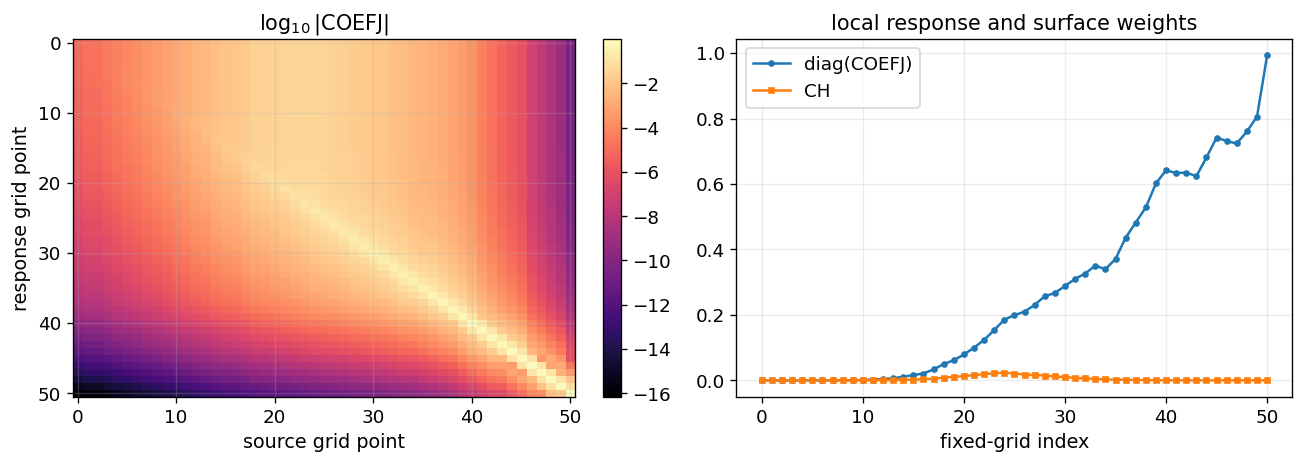

In [2]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.0))
im = a1.imshow(np.log10(np.abs(coefj_np) + 1e-30), cmap="magma", aspect="auto")
a1.set_title(r"$\log_{10}|\mathrm{COEFJ}|$")
a1.set_xlabel("source grid point")
a1.set_ylabel("response grid point")
fig.colorbar(im, ax=a1, fraction=0.046)

a2.plot(np.arange(xtau_np.size), np.diag(coefj_np), "o-", ms=3, label="diag(COEFJ)")
a2.plot(np.arange(xtau_np.size), ch_np, "s-", ms=3, label="CH")
a2.set_xlabel("fixed-grid index")
a2.set_title("local response and surface weights")
a2.legend()
fig.tight_layout()
plt.show()

## LTE source and extinction

At each depth and wavelength JOSH needs the total extinction, the scattering fraction, and the thermal source. The opacities are mass extinction coefficients, so optical depth is integrated over column mass $m$:

$$
d\tau_\lambda = \kappa_\lambda\,dm .
$$

In LTE, both the continuum and line thermal source functions reduce to the Planck function $B_\nu(T)$. We compute that source inline with Kurucz's overflow-safe per-frequency form. The reference source arrays are used only as a sanity check.

In [3]:
H_PLANCK = 6.62607015e-27
K_BOLTZ = 1.380649e-16
C_NM = 2.99792458e17
PLANCK_PREFACTOR = 1.47439e-2
EPS = 1.0e-38
ITER_TOL = 1.0e-5
MAX_ITER = 51
DEFAULT_SWEEPS = 8

def planck_bnu(wl_nm, temperature):
    """Evaluate the LTE Planck source B_nu(T) on the depth-wavelength grid.

    Parameters
    ----------
    wl_nm : torch.Tensor, shape [n_wl]
        Wavelength grid in nm.
    temperature : torch.Tensor, shape [n_depth]
        Atmospheric temperature in K.

    Returns
    -------
    torch.Tensor, shape [n_depth, n_wl]
        Per-frequency Planck source in the overflow-safe Kurucz form. This is
        the source fed to the taught solver; loaded source arrays are used only
        for a comparison sanity check.
    """
    nu = C_NM / wl_nm
    x = (H_PLANCK * nu)[None, :] / (K_BOLTZ * temperature[:, None])
    exp_minus_hnu_over_kT = torch.exp(-x)
    return PLANCK_PREFACTOR * (nu[None, :] / 1.0e15) ** 3 * exp_minus_hnu_over_kT / (1.0 - exp_minus_hnu_over_kT)

source_function = planck_bnu(wavelength_nm, temperature)

rel_slinec = torch.max(torch.abs(source_function.detach().cpu().to(torch.float64) - torch.as_tensor(D["slinec"])) / torch.abs(torch.as_tensor(D["slinec"])))
rel_lsource = torch.max(torch.abs(source_function.detach().cpu().to(torch.float64) - torch.as_tensor(D["line_source"])) / torch.abs(torch.as_tensor(D["line_source"])))
print(f"inline B_nu vs reference slinec     : max rel diff = {float(rel_slinec):.2e}")
print(f"inline B_nu vs reference line_source: max rel diff = {float(rel_lsource):.2e}")
print(f"reference line_scattering is exactly zero: {bool(np.all(line_scattering_np == 0.0))}")

def source_and_alpha(acont, scont, aline, sline, sigmac, sigmal):
    """Build total extinction, scattering fraction, and thermal source.

    All inputs have shape [batch, depth], with wavelength as the batch axis.
    `acont`/`aline` are absorptive opacity terms, `sigmac`/`sigmal` are
    scattering terms, and `scont`/`sline` are LTE thermal source functions.

    Returns
    -------
    total_extinction : torch.Tensor
        Total extinction, floored by `EPS` for safe division.
    scattering_fraction : torch.Tensor
        Scattering fraction clipped to [0, 1].
    thermal_source : torch.Tensor
        Absorption-weighted thermal source. Scattering emission is excluded
        here because it enters through the later alpha*J fixed point.
    """
    continuum_absorption = acont
    continuum_source = scont
    line_absorption = aline
    line_source = sline
    continuum_scattering = sigmac
    line_scattering = sigmal

    total_extinction = torch.clamp(
        continuum_absorption + line_absorption + continuum_scattering + line_scattering,
        min=EPS,
    )
    scattering_fraction = torch.clamp((continuum_scattering + line_scattering) / total_extinction, 0.0, 1.0)
    true_absorption = continuum_absorption + line_absorption
    thermal_source = torch.where(
        true_absorption > 0,
        (continuum_absorption * continuum_source + line_absorption * line_source) / true_absorption,
        continuum_source,
    )
    return total_extinction, scattering_fraction, thermal_source

inline B_nu vs reference slinec     : max rel diff = 6.49e-05
inline B_nu vs reference line_source: max rel diff = 6.49e-05
reference line_scattering is exactly zero: True


## Step 1 — optical depth by parabolic integration

The production solver does not use a trapezoid here. It uses Kurucz's `PARCOE`/`INTEG` pair: fit local parabolas to the extinction as a function of column mass, integrate each interval analytically, and accumulate the optical depth inward.

The implementation below is batched over wavelength. The depth dependence is a prefix sum (`torch.cumsum`), which is a native tensor primitive.

In [4]:
def parcoe_batched(f, x):
    """Return PARCOE parabolic coefficients for batched f(x).

    Parameters
    ----------
    f : torch.Tensor, shape [batch, depth]
        Values to fit on the shared depth grid, here total extinction per
        wavelength.
    x : torch.Tensor, shape [depth]
        Monotone column-mass grid.

    Returns
    -------
    (a, b, c) : tuple of torch.Tensor
        Coefficients, each shape [batch, depth], for interval-local parabolas
        f ~= a + b*x + c*x**2. The first interior intervals are forced linear,
        interior fits are curvature-blended, and the last interval is copied
        back exactly as in the JOSH/PARCOE parity path.
    """
    B, n = f.shape
    a = torch.zeros_like(f)
    b = torch.zeros_like(f)
    c = torch.zeros_like(f)
    if n == 1:
        a[:, 0] = f[:, 0]
        return a, b, c

    b[:, 0] = (f[:, 1] - f[:, 0]) / (x[1] - x[0])
    a[:, 0] = f[:, 0] - x[0] * b[:, 0]
    n1 = n - 1
    b[:, -1] = (f[:, -1] - f[:, n1 - 1]) / (x[-1] - x[n1 - 1])
    a[:, -1] = f[:, -1] - x[-1] * b[:, -1]
    if n == 2:
        return a, b, c

    xj = x[1:n1]
    xj1 = x[0:n1 - 1]
    xjp = x[2:n]
    fj = f[:, 1:n1]
    fj1 = f[:, 0:n1 - 1]
    fjp = f[:, 2:n]
    d = (fj - fj1) / (xj - xj1)
    cj = fjp / ((xjp - xj) * (xjp - xj1)) + (fj1 / (xjp - xj1) - fj / (xjp - xj)) / (xj - xj1)
    bj = d - (xj + xj1) * cj
    aj = fj1 - xj1 * d + xj * xj1 * cj
    a[:, 1:n1] = aj
    b[:, 1:n1] = bj
    c[:, 1:n1] = cj

    c[:, 1] = 0.0
    b[:, 1] = (f[:, 2] - f[:, 1]) / (x[2] - x[1])
    a[:, 1] = f[:, 1] - x[1] * b[:, 1]
    if n > 3:
        c[:, 2] = 0.0
        b[:, 2] = (f[:, 3] - f[:, 2]) / (x[3] - x[2])
        a[:, 2] = f[:, 2] - x[2] * b[:, 2]

    j = torch.arange(1, n1, device=f.device)
    j1 = torch.clamp(j + 1, max=n - 1)
    cj_cur = c[:, j]
    cj_nb = c[:, j1]
    denom = cj_nb.abs() + cj_cur.abs()
    wt = torch.where(denom > 0, cj_nb.abs() / denom, torch.zeros_like(denom))
    blended_a = a[:, j1] + wt * (a[:, j] - a[:, j1])
    blended_b = b[:, j1] + wt * (b[:, j] - b[:, j1])
    blended_c = c[:, j1] + wt * (c[:, j] - c[:, j1])
    apply = cj_cur != 0.0
    a[:, j] = torch.where(apply, blended_a, a[:, j])
    b[:, j] = torch.where(apply, blended_b, b[:, j])
    c[:, j] = torch.where(apply, blended_c, c[:, j])

    a[:, n1 - 1] = a[:, -1]
    b[:, n1 - 1] = b[:, -1]
    c[:, n1 - 1] = c[:, -1]
    return a, b, c

`INTEG` consumes those local parabolas and analytically integrates each interval. The only depth
recurrence is the cumulative sum of the interval integrals.

In [5]:
def integ_batched(x, f, start):
    """Integrate f dx cumulatively with the PARCOE/INTEG quadrature.

    Parameters
    ----------
    x : torch.Tensor, shape [depth]
        Shared column-mass grid.
    f : torch.Tensor, shape [batch, depth]
        Total extinction for each wavelength row.
    start : torch.Tensor, shape [batch]
        Surface optical-depth seed, normally f[:, 0] * x[0].

    Returns
    -------
    torch.Tensor, shape [batch, depth]
        Monochromatic optical-depth scale for every wavelength. The depth
        recurrence is a prefix sum, implemented as `torch.cumsum`.
    """
    a, b, c = parcoe_batched(f, x)
    out = torch.empty_like(f)
    out[:, 0] = start
    if f.shape[1] == 1:
        return out
    xi = x[:-1]
    xip = x[1:]
    dx = xip - xi
    term = (
        a[:, :-1]
        + 0.5 * b[:, :-1] * (xip + xi)
        + (c[:, :-1] / 3.0) * ((xip + xi) * xip + xi * xi)
    )
    out[:, 1:] = start[:, None] + torch.cumsum(term * dx, dim=1)
    return out

## Step 2 — map onto the fixed optical-depth grid

The physical atmosphere has 80 depth points, but `COEFJ` and `CH` live on the fixed 51-point `XTAU` grid. The production `MAP1` interpolation chooses a local linear, backward-parabolic, or curvature-blended parabolic fit. The tensor version below finds all brackets with `torch.searchsorted` and evaluates the same canonical parabola for every wavelength/grid pair.

In [6]:
def map1_batched(taunu, fold, xnew):
    """Interpolate fold(taunu) onto xnew with the MAP1 parabolic rule.

    Parameters
    ----------
    taunu : torch.Tensor, shape [batch, depth]
        Monotone optical-depth grid for each wavelength.
    fold : torch.Tensor, shape [batch, depth]
        Quantity to remap, usually the thermal source or scattering fraction.
    xnew : torch.Tensor, shape [n_grid]
        Fixed JOSH optical-depth grid.

    Returns
    -------
    torch.Tensor, shape [batch, n_grid]
        `fold` sampled on `xnew`. This tensor form computes the same local
        linear/backward/blended parabolas as MAP1 but uses `torch.searchsorted`
        to select every bracket in one batched operation.
    """
    B, nold = taunu.shape
    G = xnew.shape[0]
    needles = xnew[None, :].expand(B, G).contiguous()
    j0 = torch.searchsorted(taunu, needles, right=True)
    l = torch.clamp(j0 + 1, min=2, max=nold)  # 1-based Fortran bracket

    i = l - 1
    im1 = i - 1
    im2 = i - 2
    ip1 = i + 1

    def gather(src, idx):
        """Gather depth-indexed values after clamping invalid stencil endpoints."""
        return torch.gather(src, 1, torch.clamp(idx, 0, nold - 1))

    xo_i, fo_i = gather(taunu, i), gather(fold, i)
    xo_m1, fo_m1 = gather(taunu, im1), gather(fold, im1)
    xo_m2, fo_m2 = gather(taunu, im2), gather(fold, im2)
    xo_p1, fo_p1 = gather(taunu, ip1), gather(fold, ip1)

    b_lin = (fo_i - fo_m1) / (xo_i - xo_m1)
    a_lin = fo_i - xo_i * b_lin
    c_lin = torch.zeros_like(a_lin)

    d_b = (fo_m1 - fo_m2) / (xo_m1 - xo_m2)
    c_bac = fo_i / ((xo_i - xo_m1) * (xo_i - xo_m2)) + (fo_m2 / (xo_i - xo_m2) - fo_m1 / (xo_i - xo_m1)) / (xo_m1 - xo_m2)
    b_bac = d_b - (xo_m1 + xo_m2) * c_bac
    a_bac = fo_m2 - xo_m2 * d_b + xo_m1 * xo_m2 * c_bac

    d_f = (fo_i - fo_m1) / (xo_i - xo_m1)
    c_for = fo_p1 / ((xo_p1 - xo_i) * (xo_p1 - xo_m1)) + (fo_m1 / (xo_p1 - xo_m1) - fo_i / (xo_p1 - xo_i)) / (xo_i - xo_m1)
    b_for = d_f - (xo_i + xo_m1) * c_for
    a_for = fo_m1 - xo_m1 * d_f + xo_i * xo_m1 * c_for

    denom = c_for.abs() + c_bac.abs()
    wt = torch.where(c_for.abs() != 0.0, c_for.abs() / denom, torch.zeros_like(c_for))
    a_bld = a_for + wt * (a_bac - a_for)
    b_bld = b_for + wt * (b_bac - b_for)
    c_bld = c_for + wt * (c_bac - c_for)

    is_lin = (l == 2) | (l == 3)
    is_bac = (~is_lin) & (l >= nold)
    a = torch.where(is_lin, a_lin, torch.where(is_bac, a_bac, a_bld))
    b = torch.where(is_lin, b_lin, torch.where(is_bac, b_bac, b_bld))
    c = torch.where(is_lin, c_lin, torch.where(is_bac, c_bac, c_bld))
    xk = xnew[None, :]
    return a + (b + c * xk) * xk

## Step 3 — the scattering source iteration

On the fixed grid the total source obeys

$$
S_k=(1-\alpha_k)\bar S_k+\alpha_k\sum_m\mathrm{COEFJ}_{km}S_m .
$$

The production solver updates this fixed point with a backward Gauss-Seidel sweep, deepest grid point first. Isolating the diagonal term gives

$$
\Delta S_k=\frac{\alpha_k(\mathrm{COEFJ}\cdot S)_k+(1-\alpha_k)\bar S_k-S_k}
{1-\alpha_k\mathrm{COEFJ}_{kk}} .
$$

The iteration is deliberately fp32: that single-precision path is part of the reference arithmetic.

In [7]:
def iterate_source(xsbar, xalpha, coefj, coefj_diag, sweeps=DEFAULT_SWEEPS):
    """Solve the scattering fixed point by backward Gauss-Seidel sweeps.

    Parameters
    ----------
    xsbar : torch.Tensor, shape [batch, n_grid]
        Thermal source on the fixed JOSH grid.
    xalpha : torch.Tensor, shape [batch, n_grid]
        Scattering fraction on the fixed JOSH grid.
    coefj : torch.Tensor, shape [n_grid, n_grid]
        Fixed lambda-like operator, J = COEFJ @ S.
    coefj_diag : torch.Tensor, shape [n_grid]
        Diagonal of `coefj`, used in the diagonal-isolated update.
    sweeps : int
        Fixed number of backward sweeps. A fixed count keeps the GPU path
        branchless over wavelength; the default is above the convergence need
        for this window.

    Returns
    -------
    torch.Tensor, shape [batch, n_grid]
        Converged source estimate. The arithmetic is intentionally fp32 because
        the historical JOSH source iteration used single precision; changing it
        changes the parity floor.
    """
    G = xsbar.shape[1]
    co = coefj.to(torch.float32)
    cd = coefj_diag.to(torch.float32)
    al = xalpha.to(torch.float32)
    sbar = xsbar.to(torch.float32)
    eps = torch.tensor(EPS, dtype=torch.float32, device=xsbar.device)

    xsbar_mod = sbar * (1.0 - al)
    diag = 1.0 - al * cd

    # Work as [grid, wavelength] so each source row is contiguous during the 51-point scan.
    al_t = al.transpose(0, 1).contiguous()
    diag_t = diag.transpose(0, 1).contiguous()
    xsbar_mod_t = xsbar_mod.transpose(0, 1).contiguous()
    xs_t = sbar.transpose(0, 1).contiguous()

    for _ in range(sweeps):
        for k in range(G - 1, -1, -1):
            j_k = torch.matmul(co[k], xs_t)
            delta = (j_k * al_t[k] + xsbar_mod_t[k] - xs_t[k]) / diag_t[k]
            xs_t[k] = torch.maximum(xs_t[k] + delta, eps)
    return xs_t.transpose(0, 1).contiguous()

## Step 4 — batched JOSH flux

The complete tensor path is now short:

1. Build total extinction, scattering fraction, and absorption-weighted thermal source.
2. Integrate optical depth by `PARCOE`/`INTEG`.
3. Map $\bar S$ and $\alpha$ onto `XTAU`.
4. Iterate the scattering source on the fixed grid.
5. Dot with `CH` for the surface Eddington flux.

The total and continuum solves are independent, so they are stacked into one larger batch: first all total-spectrum wavelengths, then all continuum-only wavelengths.

In [8]:
def solve_josh_batched(acont, scont, aline, sline, sigmac, sigmal, rhox, sweeps=DEFAULT_SWEEPS):
    """Compute emergent Eddington flux H(0) for a wavelength batch.

    Parameters
    ----------
    acont, aline : torch.Tensor, shape [batch, depth]
        Continuum and line absorption opacity. In this notebook these are loaded
        scoped inputs, not recomputed from raw physical tables.
    sigmac, sigmal : torch.Tensor, shape [batch, depth]
        Continuum and line scattering opacity.
    scont, sline : torch.Tensor, shape [batch, depth]
        Continuum and line thermal source functions, here both inline Planck.
    rhox : torch.Tensor, shape [depth]
        Column-mass grid increasing inward.
    sweeps : int
        Fixed fp32 Gauss-Seidel sweep count.

    Returns
    -------
    torch.Tensor, shape [batch]
        Surface Eddington flux H(0). On MPS the final CH dot is fp32 because MPS
        lacks fp64; on CPU/CUDA it is promoted to fp64 to match the reference
        dot-product precision.
    """
    total_extinction, scattering_fraction, thermal_source = source_and_alpha(acont, scont, aline, sline, sigmac, sigmal)
    monochromatic_optical_depth = integ_batched(rhox, total_extinction, total_extinction[:, 0] * rhox[0])

    saturated = monochromatic_optical_depth[:, 0] > XTAU[-1]
    if bool(saturated.any()):
        raise NotImplementedError("The saturated-core path does not fire in this solar window.")

    thermal_source_fixed_grid = torch.clamp(map1_batched(monochromatic_optical_depth, thermal_source, XTAU), min=EPS)
    scattering_fraction_fixed_grid = torch.clamp(map1_batched(monochromatic_optical_depth, scattering_fraction, XTAU), 0.0, 1.0)

    above = XTAU[None, :] < monochromatic_optical_depth[:, 0:1]
    thermal_source_fixed_grid = torch.where(
        above,
        torch.clamp(thermal_source[:, 0:1], min=EPS).expand_as(thermal_source_fixed_grid),
        thermal_source_fixed_grid,
    )
    scattering_fraction_fixed_grid = torch.where(
        above,
        torch.clamp(scattering_fraction[:, 0:1], 0.0, 1.0).expand_as(scattering_fraction_fixed_grid),
        scattering_fraction_fixed_grid,
    )

    source_function_fixed_grid = iterate_source(
        thermal_source_fixed_grid,
        scattering_fraction_fixed_grid,
        COEFJ,
        COEFJ_DIAG,
        sweeps=sweeps,
    )
    dot_dtype = torch.float32 if DEVICE.type == "mps" else torch.float64
    return torch.matmul(source_function_fixed_grid.to(dot_dtype), CH.to(dot_dtype))

The final wrapper stacks the full-spectrum and continuum-only solves into one batch. This makes
the comparison spectrum a direct consequence of two JOSH flux solves, not a loaded ratio.

In [9]:
def solve_spectrum(continuum_absorption, continuum_scattering, line_absorption, line_scattering,
                   source_function, column_mass, sweeps=DEFAULT_SWEEPS):
    """Solve total and continuum spectra with one stacked JOSH batch.

    Parameters
    ----------
    continuum_absorption, continuum_scattering, line_absorption, line_scattering : torch.Tensor, shape [depth, n_wl]
        Opacity slabs for the window. These are the remaining taught-path data
        boundary in this L8 patch: they are consumed as scoped inputs rather
        than regenerated here from Lectures 3-6.
    source_function : torch.Tensor, shape [depth, n_wl]
        Inline LTE Planck source.
    column_mass : torch.Tensor, shape [depth]
        Column-mass grid.
    sweeps : int
        Fixed fp32 source-iteration sweep count.

    Returns
    -------
    (flux_total, flux_cont, spectrum) : tuple of torch.Tensor
        Total flux, continuum-only flux, and their normalised ratio. The
        comparison target is loaded separately and is not used by this function.
    """
    continuum_absorption_batch = continuum_absorption.transpose(0, 1).contiguous()
    continuum_scattering_batch = continuum_scattering.transpose(0, 1).contiguous()
    line_absorption_batch = line_absorption.transpose(0, 1).contiguous()
    line_scattering_batch = line_scattering.transpose(0, 1).contiguous()
    source_batch = source_function.transpose(0, 1).contiguous()
    zero_line_opacity = torch.zeros_like(line_absorption_batch)

    continuum_absorption_stacked = torch.cat((continuum_absorption_batch, continuum_absorption_batch), dim=0)
    source_stacked = torch.cat((source_batch, source_batch), dim=0)
    line_absorption_stacked = torch.cat((line_absorption_batch, zero_line_opacity), dim=0)
    continuum_scattering_stacked = torch.cat((continuum_scattering_batch, continuum_scattering_batch), dim=0)
    line_scattering_stacked = torch.cat((line_scattering_batch, zero_line_opacity), dim=0)

    surface_flux = solve_josh_batched(
        continuum_absorption_stacked,
        source_stacked,
        line_absorption_stacked,
        source_stacked,
        continuum_scattering_stacked,
        line_scattering_stacked,
        column_mass,
        sweeps=sweeps,
    )
    n_wl = source_batch.shape[0]
    flux_total = surface_flux[:n_wl]
    flux_cont = surface_flux[n_wl:]
    return flux_total, flux_cont, flux_total / flux_cont

## A worked example: continuum versus line core

The continuum surface can be scattering dominated because true absorption becomes tiny in the top layers, while the deep line cores in this solar window are almost pure absorption because the line opacity swamps the continuum scattering. The iteration matters where $\alpha$ is large, not simply where a spectral feature is deep.

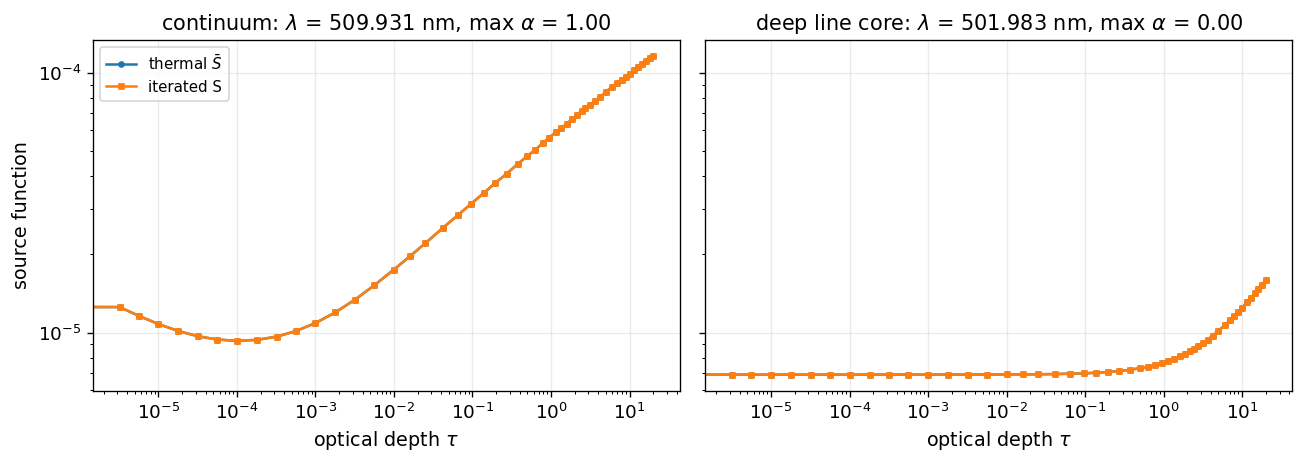

In [10]:
reference = flux_total_ref_np / flux_cont_ref_np
kc = int(np.argmin(reference))
kk = int(np.argmin(np.abs(reference - 1.0)))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.0), sharey=True)
for ax, k, name in [(axes[0], kk, "continuum"), (axes[1], kc, "deep line core")]:
    continuum_absorption_slice = continuum_absorption[:, [k]].T.contiguous()
    continuum_scattering_slice = continuum_scattering[:, [k]].T.contiguous()
    line_absorption_slice = line_absorption[:, [k]].T.contiguous()
    line_scattering_slice = line_scattering[:, [k]].T.contiguous()
    source_slice = source_function[:, [k]].T.contiguous()
    total_extinction, scattering_fraction, thermal_source = source_and_alpha(
        continuum_absorption_slice,
        source_slice,
        line_absorption_slice,
        source_slice,
        continuum_scattering_slice,
        line_scattering_slice,
    )
    monochromatic_optical_depth = integ_batched(column_mass, total_extinction, total_extinction[:, 0] * column_mass[0])
    thermal_source_fixed_grid = torch.clamp(map1_batched(monochromatic_optical_depth, thermal_source, XTAU), min=EPS)
    scattering_fraction_fixed_grid = torch.clamp(map1_batched(monochromatic_optical_depth, scattering_fraction, XTAU), 0.0, 1.0)
    above = XTAU[None, :] < monochromatic_optical_depth[:, 0:1]
    thermal_source_fixed_grid = torch.where(
        above,
        torch.clamp(thermal_source[:, 0:1], min=EPS).expand_as(thermal_source_fixed_grid),
        thermal_source_fixed_grid,
    )
    scattering_fraction_fixed_grid = torch.where(
        above,
        torch.clamp(scattering_fraction[:, 0:1], 0.0, 1.0).expand_as(scattering_fraction_fixed_grid),
        scattering_fraction_fixed_grid,
    )
    source_function_fixed_grid = iterate_source(thermal_source_fixed_grid, scattering_fraction_fixed_grid, COEFJ, COEFJ_DIAG)

    ax.loglog(xtau_np, thermal_source_fixed_grid[0].detach().cpu().numpy(), "o-", ms=3, label=r"thermal $\bar S$")
    ax.loglog(xtau_np, source_function_fixed_grid[0].detach().cpu().numpy(), "s-", ms=3, label="iterated S")
    ax.set_title(f"{name}: $\\lambda$ = {wavelength_nm_np[k]:.3f} nm, max $\\alpha$ = {float(scattering_fraction_fixed_grid.max().detach().cpu()):.2f}")
    ax.set_xlabel(r"optical depth $\tau$")

axes[0].set_ylabel("source function")
axes[0].legend(loc="upper left", fontsize=9)
fig.tight_layout()
plt.show()

## The full spectrum

Now run the batched tensor solver over the whole 500--510 nm window. The ratio of the total and continuum fluxes is compared directly with the shipped production spectrum.

In [11]:
flux_total, flux_cont, spectrum_t = solve_spectrum(
    continuum_absorption,
    continuum_scattering,
    line_absorption,
    line_scattering,
    source_function,
    column_mass,
)
spectrum = spectrum_t.detach().cpu().to(torch.float64).numpy()
reference = flux_total_ref_np / flux_cont_ref_np
rel = np.abs(spectrum - reference) / np.abs(reference)

print(f"normalised spectrum vs reference: median |rel diff| = {np.median(rel):.2e}, max = {rel.max():.2e}")
print(f"worst wavelength = {wavelength_nm_np[int(np.argmax(rel))]:.6f} nm")
assert np.median(rel) < 2e-7
assert rel.max() < 5e-5

normalised spectrum vs reference: median |rel diff| = 7.95e-08, max = 1.30e-05
worst wavelength = 501.979677 nm


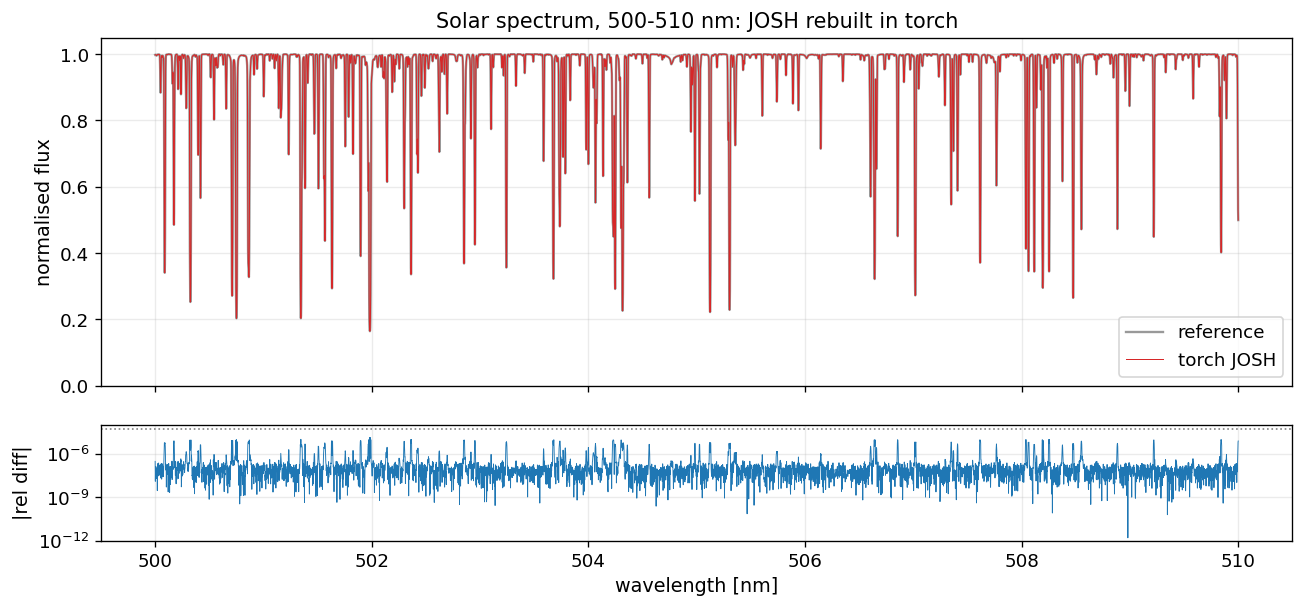

In [12]:
fig, (ax, axr) = plt.subplots(2, 1, figsize=(11, 5.2), sharex=True, gridspec_kw={"height_ratios": [3, 1]})
ax.plot(wavelength_nm_np, reference, color="0.6", lw=1.4, label="reference")
ax.plot(wavelength_nm_np, spectrum, color="C3", lw=0.6, label="torch JOSH")
ax.set_ylabel("normalised flux")
ax.set_ylim(0, 1.05)
ax.set_title("Solar spectrum, 500-510 nm: JOSH rebuilt in torch")
ax.legend(loc="lower right")

axr.semilogy(wavelength_nm_np, np.maximum(rel, 1e-16), color="C0", lw=0.55)
axr.axhline(5e-5, color="0.5", ls=":", lw=1)
axr.set_xlabel("wavelength [nm]")
axr.set_ylabel("|rel diff|")
axr.set_ylim(1e-12, 1e-4)
fig.tight_layout()
plt.show()

## A note on saturated cores

The original JOSH implementation has a fallback for a rare case: if the top atmospheric layer is already deeper than the largest fixed-grid point, the ordinary map onto `XTAU` no longer samples the line-forming region. In that saturated-core branch the code switches to a local surface treatment instead of pretending the fixed grid still brackets the problem.

That branch does **not** fire in this 500--510 nm solar window. The notebook checks this in `solve_josh_batched` and raises if it ever happens, rather than silently taking an unimplemented path. This is an honest boundary, not a hidden approximation: every wavelength in the current benchmark uses the ordinary parabolic optical-depth integration, `MAP1`-style remap, source iteration, and `CH` flux weights.

## Numerical caveats and closure status

The algorithmic parity is clean on the scoped inputs: the same fixed grid, parabolic quadrature/interpolation, operator, scattering update, and flux weights are used. The remaining differences are numerical:

- The Gauss-Seidel source iteration is fp32 by specification, matching the original production arithmetic.
- On CPU the structural tensor steps can use fp64 and the residual is near the single-precision iteration floor.
- On Apple MPS the whole resident tensor path is fp32 because MPS has no fp64; the worst residual is therefore a GPU format floor rather than a physics or algorithm discrepancy.
- The saturated-core path, where the top layer is already deeper than the fixed grid, does not fire in this solar optical window and is deliberately left out here.

The fixture boundary is explicit: precomputed opacity slabs and fixed operator tables are taught-path inputs for this transfer solve. The loaded source arrays and flux arrays are comparison-only; they are not fed into `solve_spectrum`.

## Synthesis

Lecture 7 gave the transparent formal solution: choose a source, integrate it against the $E_2$ kernel, and understand line formation through the $\tau_\lambda \approx 2/3$ surface. This lecture rebuilt the production transfer engine that closes the remaining deep-core method gap. The source is mapped onto the fixed `XTAU` grid with the same parabolic interpolation rule, the scattering term is solved as a fixed point with the tabulated `COEFJ` operator, and the surface flux is the `CH` weighted sum.

The GPU translation changes the shape, not the method. Wavelength is the batch axis; optical-depth construction, source remapping, and the final flux dot all operate on whole wavelength batches. The one intentionally small loop is the 51-point backward Gauss-Seidel source sweep, because that is the ordered update specified by the JOSH arithmetic. The resulting spectrum matches the shipped production reference within the documented torch precision floor.

With this, the course has a complete forward synthesis chain for the solar 500--510 nm window: atmosphere and populations, continuum opacity, metal/helium/hydrogen line opacity, and now the production radiative-transfer solver. The remaining physical expansion is not hidden in this transfer notebook: later parts replace the prescribed atmosphere with hydrostatic and radiative-equilibrium structure and add molecules for cool-star spectra.

## Summary

- The Eddington closure turns moment transfer into a linear operator on the source, shipped as `COEFJ`.
- JOSH maps each wavelength onto a fixed 51-point optical-depth grid, iterates the scattering source, and forms $H(0)$ with `CH`.
- The executable path in this notebook is torch-native and batched over wavelength; it imports no production solver code.
- The rebuilt spectrum matches the shipped reference to the documented torch precision floor.
- Opacity slabs and JOSH operator tables are scoped taught-path inputs for this transfer-kernel lecture; source arrays and flux arrays are comparison-only.
- The saturated-core fallback is named and guarded; it does not fire in this solar optical window.

## Practice exercises

**1. Precision budget.** Force `DEVICE=torch.device("cpu")` and `DTYPE=torch.float64`, rebuild, and compare the residual with the MPS run. Which cells move, and why?

**2. Scattering switch.** Set `cont_scat` and `line_scat` to zero before `solve_spectrum`. Which wavelengths change most, and how does that relate to the plotted $\alpha$ values?

**3. Operator reach.** Plot rows 5, 25, and 45 of `COEFJ`. How local is the lambda operator near the surface, middle, and deep grid?

**4. Fixed sweeps.** Change `DEFAULT_SWEEPS` from 8 to 3, 5, and 12. How quickly does the spectrum converge, and where do insufficient sweeps first show up?

## Further reading

- **Mihalas, D. (1978). *Stellar Atmospheres*, 2nd ed., Freeman.** The classical derivation of radiative-transfer moments, closure relations, and source-function iteration.
- **Avrett, E. H. & Loeser, R.** The line of work behind the JOSH/Avrett-style moment solver and fixed optical-depth operators used in the Kurucz codes.
- **Kurucz, R. L. ATLAS/SYNTHE documentation.** The source of the parabolic optical-depth integration, fixed JOSH tables, and surface-flux weights reproduced here.
- **Hubeny, I. & Mihalas, D. (2014). *Theory of Stellar Atmospheres*, Princeton.** A modern reference for lambda operators, scattering source functions, and accelerated iteration.
- **Kim, E. M. & Ting, Y.-S. (2026). [*pykurucz*](https://arxiv.org/abs/2603.11693).** The reference implementation used to produce the parity fixtures.